In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.decomposition import PCA


In [5]:
from sklearn.cluster import KMeans


In [6]:
print("Libraries imported successfully")

Libraries imported successfully


In [7]:
titanic = sns.load_dataset("titanic")


In [8]:
print("Dataset loaded successfully")


Dataset loaded successfully


In [9]:
print("Dataset Shape:", titanic.shape)

Dataset Shape: (891, 15)


In [11]:
print("\nFirst 5 Rows:")
display(titanic.head())


First 5 Rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
data = titanic[["pclass", "age", "sibsp", "parch", "fare"]].copy()


In [14]:
print("Selected Features: ")
display(data.head())


Selected Features: 


,pclass,age,sibsp,parch,fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500


In [15]:
print("\nDataset Shape:", data.shape)


Dataset Shape: (891, 5)


In [16]:
print("Missing Values Before Preprocessing:")


Missing Values Before Preprocessing:


In [17]:
print(data.isnull().sum())


pclass      0
age       177
sibsp       0
parch       0
fare        0
dtype: int64


In [18]:
data["age"] = data["age"].fillna(data["age"].median())


In [19]:
print("\nMissing Values After Preprocessing:")
print(data.isnull().sum())



Missing Values After Preprocessing:
pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64


In [20]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


In [21]:
print("Data standardized successfully")


Data standardized successfully


In [22]:
print("\nFirst 5 Rows of Scaled Data:")
print(scaled_data[:5])



First 5 Rows of Scaled Data:
[[ 0.82737724 -0.56573646  0.43279337 -0.47367361 -0.50244517]
 [-1.56610693  0.66386103  0.43279337 -0.47367361  0.78684529]
 [ 0.82737724 -0.25833709 -0.4745452  -0.47367361 -0.48885426]
 [-1.56610693  0.4333115   0.43279337 -0.47367361  0.42073024]
 [ 0.82737724  0.4333115  -0.4745452  -0.47367361 -0.48633742]]


In [23]:
pca = PCA(n_components=2)


In [25]:
pca_data = pca.fit_transform(scaled_data)
print("PCA applied successfully")


PCA applied successfully


In [26]:
print("Shape after PCA:", pca_data.shape)


Shape after PCA: (891, 2)


In [27]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.33960812 0.32520788]


In [28]:
pca_df = pd.DataFrame(pca_data, columns=["Principal Component 1", "Principal Component 2"])
print("First 5 Rows after PCA:")
display(pca_df.head())


First 5 Rows after PCA:


,Principal Component 1,Principal Component 2
0,1.140660,-0.076520
1,-1.768445,0.133479
2,0.879196,-0.726606
3,-1.458103,0.071555
4,0.561252,-0.943713


In [29]:
inertia = []


In [30]:
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)


In [31]:
print("Inertia Values:")
print(inertia)


Inertia Values:
[2961.7552664359882, 1853.7888433867754, 1022.3541334963675, 771.6825312188652, 591.892513880619, 490.56424972186846, 418.17143122515574]


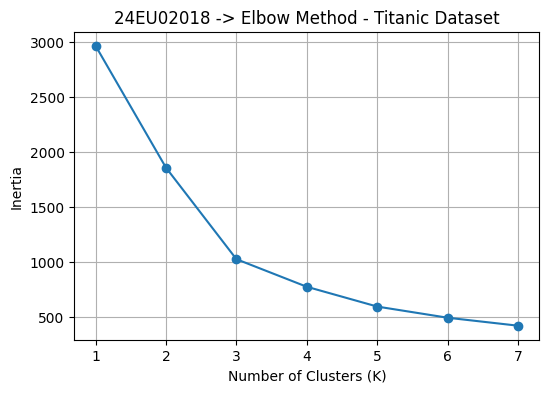

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, 8), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("24EU02018 -> Elbow Method - Titanic Dataset")
plt.grid(True)
plt.show()


In [33]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)
pca_df["Cluster"] = clusters
print("K-Means clustering completed successfully")


K-Means clustering completed successfully


In [35]:
print("\nNumber of Passengers in Each Cluster:")
print(pca_df["Cluster"].value_counts().sort_index())



Number of Passengers in Each Cluster:
Cluster
0    106
1    550
2    235
Name: count, dtype: int64


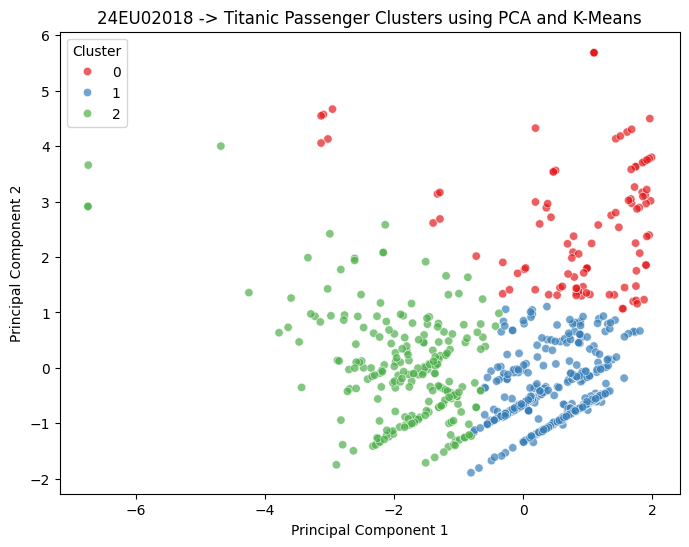

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="Principal Component 1", y="Principal Component 2",
                hue="Cluster", palette="Set1", alpha=0.7)
plt.title("24EU02018 -> Titanic Passenger Clusters using PCA and K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [38]:
print("Cluster Centers in PCA Space:")
centers = pd.DataFrame(kmeans.cluster_centers_,
                       columns=["Principal Component 1", "Principal Component 2"])
display(centers)


Cluster Centers in PCA Space:


,Principal Component 1,Principal Component 2
0,0.854491,2.695503
1,0.599990,-0.506212
2,-1.789661,-0.031093


In [39]:
print("Original Number of Features:", data.shape[1])


Original Number of Features: 5


In [40]:
print("\nExplained Variance by PCA:")
print(round(pca.explained_variance_ratio_.sum() * 100, 2), "%")



Explained Variance by PCA:
66.48 %


In [41]:
print("\nCluster Distribution:")
print(pca_df["Cluster"].value_counts().sort_index())



Cluster Distribution:
Cluster
0    106
1    550
2    235
Name: count, dtype: int64
